<div style="display:flex; align-items:center; gap:20px;">

<div>

# Politechnika Bydgoska im. Jana i Jędrzeja Śniadeckich  
### Wydział Telekomunikacji, Informatyki i Elektrotechniki  
al. prof. S. Kaliskiego 7, 85-796 Bydgoszcz

# Przedmiot – Drzewa Decyzyjne 

</div>
</div>

---

# Laboratorium 3 – Uczenie bez nadzoru 

<table>
<tr>
<td><b>Przedmiot</b></td>
<td>Drzewa Decyzyjne</td>
<td><b>Kierunek / Tryb</b></td>
<td>Informatyka Stosowana</td>
</tr>

<tr>
<td><b>Nr laboratorium</b></td>
<td>3</td>
<td><b>Data wykonania</b></td>
<td>26.03.2026</td>
</tr>

<tr>
<td><b>Grupa</b></td>
<td>4</td>
<td><b>Data oddania</b></td>
<td></td>
</tr>

<tr>
<td><b>Ocena</b></td>
<td></td>
<td></td>
<td></td>
</tr>
</table>

---

### Autorzy

- Maciej Kwiatkowski  
- Mikołaj Gawroński  
- Mateusz Machowski  

---

Zadanie 1. (1 pkt.)
Zbiór danych: Higher Education Students Performance Evaluation - UCI Machine Learning
Repository
Dane dotyczące transakcji różnych produktów na przestrzeni 51-tygodni zawierają zarówno
wartości oryginalne jak i znormalizowane.


In [12]:
!pip install ucimlrepo scikit-learn-extra


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

In [14]:
dataset = fetch_ucirepo(id=856)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

print("Wymiar X:", X.shape)
display(X.head())

Wymiar X: (145, 31)


,Student Age,Sex,Graduated high-school type,Scholarship type,Additional work,Regular artistic or sports activity,Do you have a partner,Total salary if available,Transportation to the university,Accomodation type in Cyprus,...,Attendance to classes,Preparation to midterm exams 1,Preparation to midterm exams 2,Taking notes in classes,Listening in classes,Discussion improves my interest and success in the course,Flip-classroom,Cumulative grade point average in the last semester (/4.00),Expected Cumulative grade point average in the graduation (/4.00),Course ID
0,2,2,3,3,1,2,2,1,1,1,...,1,1,1,3,2,1,2,1,1,1
1,2,2,3,3,1,2,2,1,1,1,...,1,1,1,3,2,3,2,2,3,1
2,2,2,2,3,2,2,2,2,4,2,...,1,1,1,2,2,1,1,2,2,1
3,1,1,1,3,1,2,1,2,1,2,...,1,1,2,3,2,2,1,3,2,1
4,2,2,1,3,2,2,1,3,1,4,...,1,2,1,2,2,2,1,2,2,1


Zadanie 2. (3 pkt.)
Wykonaj analizę skupień danych dla następujących algorytmów:
• K-MEANS
• K-MEANS++
• *K-MEDIOD
W wyniku analizy skupień dodaj do każdej próbki kategorię odpowiadającą przypisanemu
klastrowi (zakładamy kategorie całkowite: 1,2,3,….).
W zaimplementowanych algorytmach jako argument użytkownik może wprowadzić liczbę
klastrów (domyślnie 5).
Przedstaw graficznie (na wspólnym wykresie) wyniki analizy skupień dla w/w metod:
• Każdy klaster powinien być zaprezentowany unikatowym kolorem oraz stylem punktu
(np. czerwone kółko, niebieski kwadrat, itp).
• Dla każdego klastra wyznacz centrum klastra.

In [15]:
k = 5
random_state = 42

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_2d = PCA(n_components=2, random_state=random_state)
X_2d = pca_2d.fit_transform(X_scaled)

In [17]:
kmeans_random = KMeans(
    n_clusters=k,
    init="random",
    n_init=10,
    random_state=random_state
)
labels_kmeans_random = kmeans_random.fit_predict(X_scaled)

kmeans_pp = KMeans(
    n_clusters=k,
    init="k-means++",
    n_init=10,
    random_state=random_state
)
labels_kmeans_pp = kmeans_pp.fit_predict(X_scaled)

kmedoids = KMedoids(
    n_clusters=k,
    random_state=random_state
)
labels_kmedoids = kmedoids.fit_predict(X_scaled)

In [18]:
print("Liczebności klastrów - KMeans:")
print(pd.Series(labels_kmeans_random + 1).value_counts().sort_index())

print("\nLiczebności klastrów - KMeans++:")
print(pd.Series(labels_kmeans_pp + 1).value_counts().sort_index())

print("\nLiczebności klastrów - KMedoids:")
print(pd.Series(labels_kmedoids + 1).value_counts().sort_index())

Liczebności klastrów - KMeans:
1    32
2    28
3    12
4    41
5    32
Name: count, dtype: int64

Liczebności klastrów - KMeans++:
1    16
2    15
3    25
4    39
5    50
Name: count, dtype: int64

Liczebności klastrów - KMedoids:
1    30
2    35
3    27
4    30
5    23
Name: count, dtype: int64


In [19]:
centers_kmeans_random_2d = pca_2d.transform(kmeans_random.cluster_centers_)
centers_kmeans_pp_2d = pca_2d.transform(kmeans_pp.cluster_centers_)
centers_kmedoids_2d = X_2d[kmedoids.medoid_indices_]

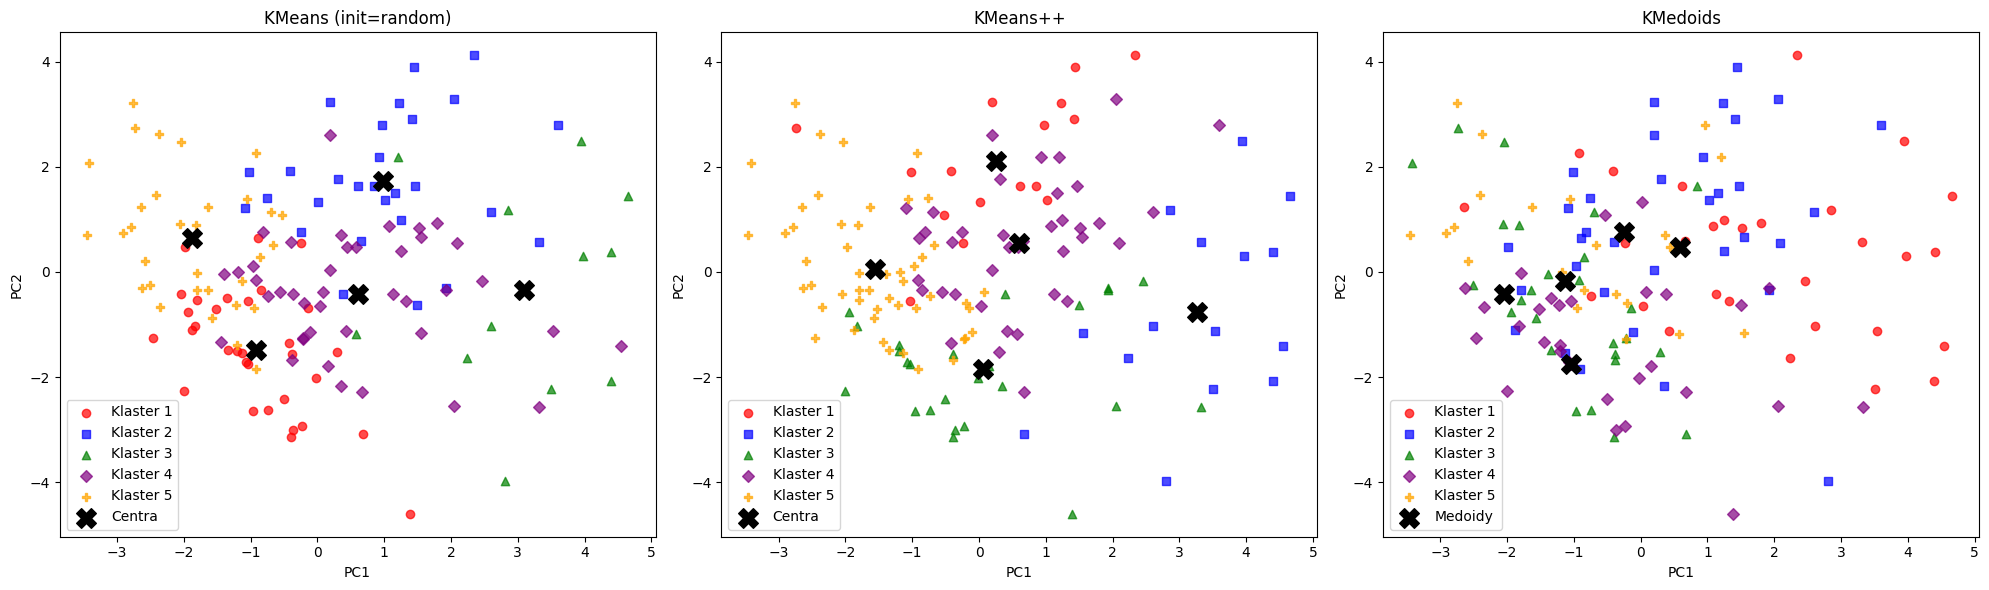

In [20]:
markers = ['o', 's', '^', 'D', 'P', 'X', '*', 'v', '<', '>']
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for cluster_id in range(k):
    mask = labels_kmeans_random == cluster_id
    axes[0].scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        c=colors[cluster_id],
        marker=markers[cluster_id],
        label=f'Klaster {cluster_id + 1}',
        alpha=0.7
    )

axes[0].scatter(
    centers_kmeans_random_2d[:, 0],
    centers_kmeans_random_2d[:, 1],
    c='black',
    marker='X',
    s=200,
    label='Centra'
)
axes[0].set_title('KMeans (init=random)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

for cluster_id in range(k):
    mask = labels_kmeans_pp == cluster_id
    axes[1].scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        c=colors[cluster_id],
        marker=markers[cluster_id],
        label=f'Klaster {cluster_id + 1}',
        alpha=0.7
    )

axes[1].scatter(
    centers_kmeans_pp_2d[:, 0],
    centers_kmeans_pp_2d[:, 1],
    c='black',
    marker='X',
    s=200,
    label='Centra'
)
axes[1].set_title('KMeans++')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

for cluster_id in range(k):
    mask = labels_kmedoids == cluster_id
    axes[2].scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        c=colors[cluster_id],
        marker=markers[cluster_id],
        label=f'Klaster {cluster_id + 1}',
        alpha=0.7
    )

axes[2].scatter(
    centers_kmedoids_2d[:, 0],
    centers_kmedoids_2d[:, 1],
    c='black',
    marker='X',
    s=200,
    label='Medoidy'
)
axes[2].set_title('KMedoids')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend()

plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import silhouette_score

print("Silhouette - KMeans:", silhouette_score(X_scaled, labels_kmeans_random))
print("Silhouette - KMeans++:", silhouette_score(X_scaled, labels_kmeans_pp))
print("Silhouette - KMedoids:", silhouette_score(X_scaled, labels_kmedoids))

Silhouette - KMeans: 0.054052399288902944
Silhouette - KMeans++: 0.050451007619044724
Silhouette - KMedoids: 0.02591279072863826


## Zadanie 3.
Wykonaj klasteryzacje dla tego samego zbioru danych na podstawie algorytmów:<br>
    - AgglomerativeClustering z dowolnym typem klasteryzacji, typem wiązania oraz metryką
    odległości<br>
    - DBSCAN z domyślnymi wartościami argumentów<br><br>
Zaprezentuj graficznie (na jednym wykresie) wyniki klasteryzacji:<br>
    - Klasteryzacja aglomeracyjna – dendrogram + mapa cieplna

Importy oraz wczytanie danych:

In [22]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram
import seaborn as sns

dane = X.copy()

print("wymiar danych:", dane.shape)
print("nazwy kolumn:")
for nazwa in dane.columns:
    print("-", nazwa)

print()
print("podglad danych:")
print(dane.head())

wymiar danych: (145, 31)
nazwy kolumn:
- Student Age
- Sex
- Graduated high-school type
- Scholarship type
- Additional work
- Regular artistic or sports activity
- Do you have a partner
- Total salary if available
- Transportation to the university
- Accomodation type in Cyprus
- Mother's education
- Father's education
- Number of sisters/brothers (if available)
- Parental status
- Mother's occupation
- Father's occupation
- Weekly study hours
- Reading frequency (non-scientific books/journals)
- Reading frequency (scientific books/journals)
- Attendance to the seminars/conferences related to the department
- Impact of your projects/activities on your success
- Attendance to classes
- Preparation to midterm exams 1
- Preparation to midterm exams 2
- Taking notes in classes
- Listening in classes
- Discussion improves my interest and success in the course
- Flip-classroom
- Cumulative grade point average in the last semester (/4.00)
- Expected Cumulative grade point average in the grad

Przygotowuje dane do klasteryzacji:

In [23]:
#przygotowanie danych do klasteryzacji
dane = X.copy()
dane_model = dane.copy()
dane_norm = X_scaled

print("wymiar danych:", dane.shape)
print("dane zostaly przygotowane do klasteryzacji.")

wymiar danych: (145, 31)
dane zostaly przygotowane do klasteryzacji.


<b>Klasteryzacja aglomeracyjna:</b> <br>
Stosuje algorytm 'AgglomerativeClustering' z liczba klastrów równą 5 oraz metodą wiązania 'ward'. Po dopasowaniu modelu do danych każdej próbce przypisuje numer klastra. Otrzymany wynik zapisuje do pliku 'wynik_aglomeracyjny.csv'

In [24]:
model_aglo = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

etykiety_aglo = model_aglo.fit_predict(dane_norm)

#zamieniam etykiety 0,1,2... na 1,2,3...
klastry_aglo = etykiety_aglo + 1

print("unikatowe etykiety aglomeracyjne:", np.unique(klastry_aglo))
print("liczebnosc klastrow:")
print(pd.Series(klastry_aglo).value_counts().sort_index())
print()

#zbior wynikowy
wynik_aglo = dane.copy()
wynik_aglo["KLASTER_AGLO"] = klastry_aglo

print("podglad danych po klasteryzacji aglomeracyjnej:")
print(wynik_aglo.head())

#zapis do csv'ki
wynik_aglo.to_csv("wynik_aglomeracyjny.csv", sep=";", index=False)
print()
print("zapisano plik wynik_aglomeracyjny.csv")

unikatowe etykiety aglomeracyjne: [1 2 3 4 5]
liczebnosc klastrow:
1    44
2    48
3    26
4     2
5    25
Name: count, dtype: int64

podglad danych po klasteryzacji aglomeracyjnej:
   Student Age  Sex  Graduated high-school type  Scholarship type  \
0            2    2                           3                 3   
1            2    2                           3                 3   
2            2    2                           2                 3   
3            1    1                           1                 3   
4            2    2                           1                 3   

   Additional work  Regular artistic or sports activity  \
0                1                                    2   
1                1                                    2   
2                2                                    2   
3                1                                    2   
4                2                                    2   

   Do you have a partner  Total salary if availa

dendrogram dla klasteryzacji aglomeracyjnej:

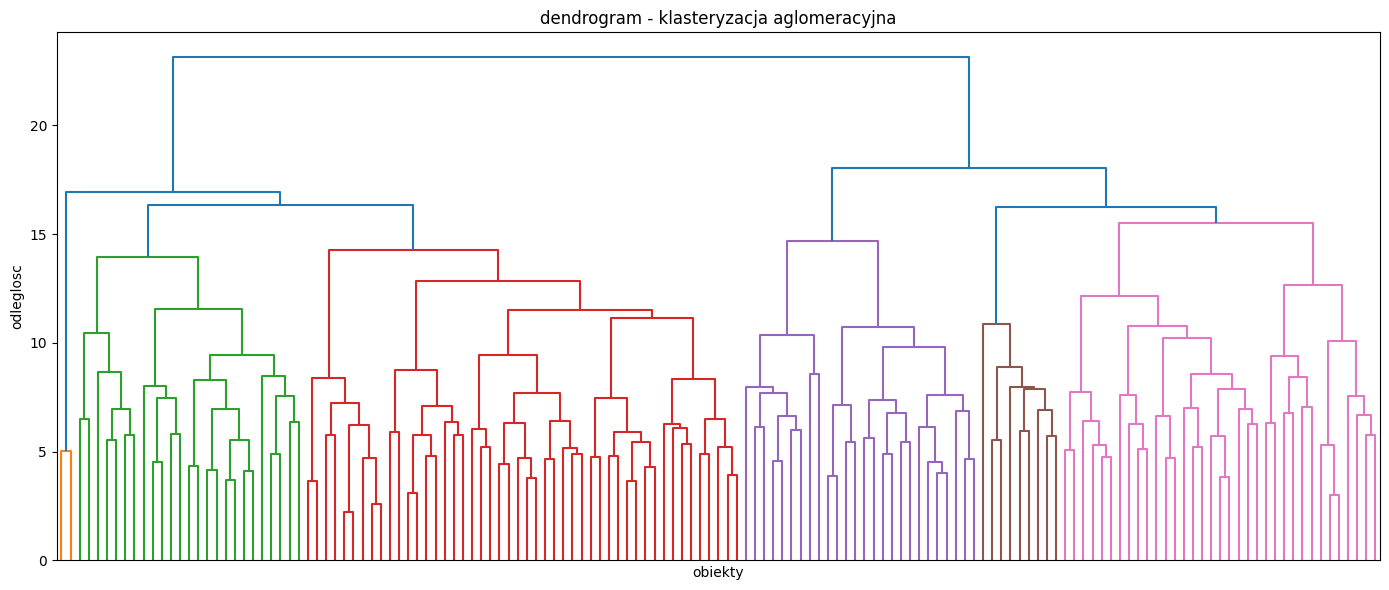

In [25]:
macierz_polaczen = linkage(dane_norm, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(macierz_polaczen, no_labels=True)
plt.title("dendrogram - klasteryzacja aglomeracyjna")
plt.xlabel("obiekty")
plt.ylabel("odleglosc")
plt.tight_layout()
plt.show()

dendrogram pokazuje nam sposób łączenia obiektów w klastry

Mapa cieplna z grupowaniem:

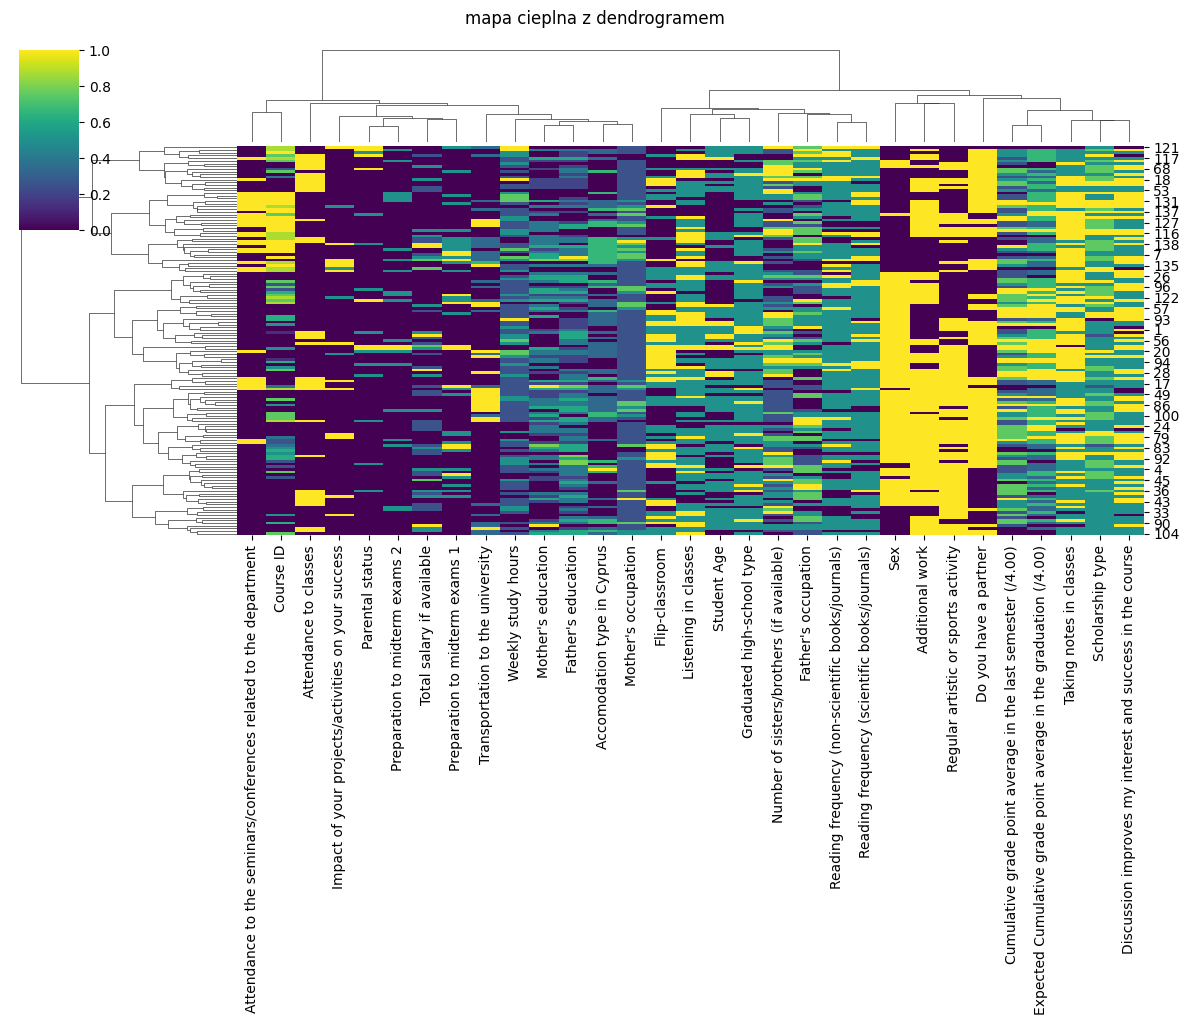

In [26]:
sns.clustermap(
    dane_model,
    method="ward",
    metric="euclidean",
    standard_scale=1,
    cmap="viridis",
    figsize=(12, 10)
)

plt.suptitle("mapa cieplna z dendrogramem", y=1.02)
plt.show()

mapa cieplna pozwala nam zauważyć podobieństwa pomiędzy próbkami i cechami

Klasteryzacja DBSCAN:

In [27]:
model_db = DBSCAN()
etykiety_db = model_db.fit_predict(dane_norm)

print("surowe etykiety DBSCAN:", np.unique(etykiety_db))

# mapowanie do kategorii 1,2,3,...
unikalne = sorted(np.unique(etykiety_db))
mapowanie = {wartosc: i + 1 for i, wartosc in enumerate(unikalne)}

kategorie_db = np.array([mapowanie[x] for x in etykiety_db])

print("mapowanie etykiet:", mapowanie)
print("kategorie koncowe:", np.unique(kategorie_db))

wynik_db = dane.copy()
wynik_db["DBSCAN_raw"] = etykiety_db
wynik_db["DBSCAN_kategoria"] = kategorie_db

print(wynik_db.head())

wynik_db.to_csv("wynik_dbscan.csv", sep=";", index=False)
print("zapisano plik wynik_dbscan.csv")

surowe etykiety DBSCAN: [-1]
mapowanie etykiet: {np.int64(-1): 1}
kategorie koncowe: [1]
   Student Age  Sex  Graduated high-school type  Scholarship type  \
0            2    2                           3                 3   
1            2    2                           3                 3   
2            2    2                           2                 3   
3            1    1                           1                 3   
4            2    2                           1                 3   

   Additional work  Regular artistic or sports activity  \
0                1                                    2   
1                1                                    2   
2                2                                    2   
3                1                                    2   
4                2                                    2   

   Do you have a partner  Total salary if available  \
0                      2                          1   
1                      2       

DBSCAN z parametrami domyślnymi (eps=0.5, min_samples=5) nie wykrył żadnych skupień. Wszystkie obserwacje otrzymały etykietę -1, czyli zostały uznane za szum. Z uwagi na wymaganie zapisania kategorii całkowitej do zbioru wynikowego, pomocniczo odwzorowałem -1 na kategorię techniczną, ale nie należy interpretować jej jako rzeczywistego klastra.

Przygotowanie danych do wykresu DBSCAN:

In [28]:
punkty_2d = X_2d

ramka_wykres = pd.DataFrame(punkty_2d, columns=["x", "y"])
ramka_wykres["raw"] = etykiety_db
ramka_wykres["kategoria"] = kategorie_db

Ponieważ danych jest dużo i mają one wiele kolumn musiałem je sprowadzić do 2 wymiarów

Wykres klastrów DBSCAN:

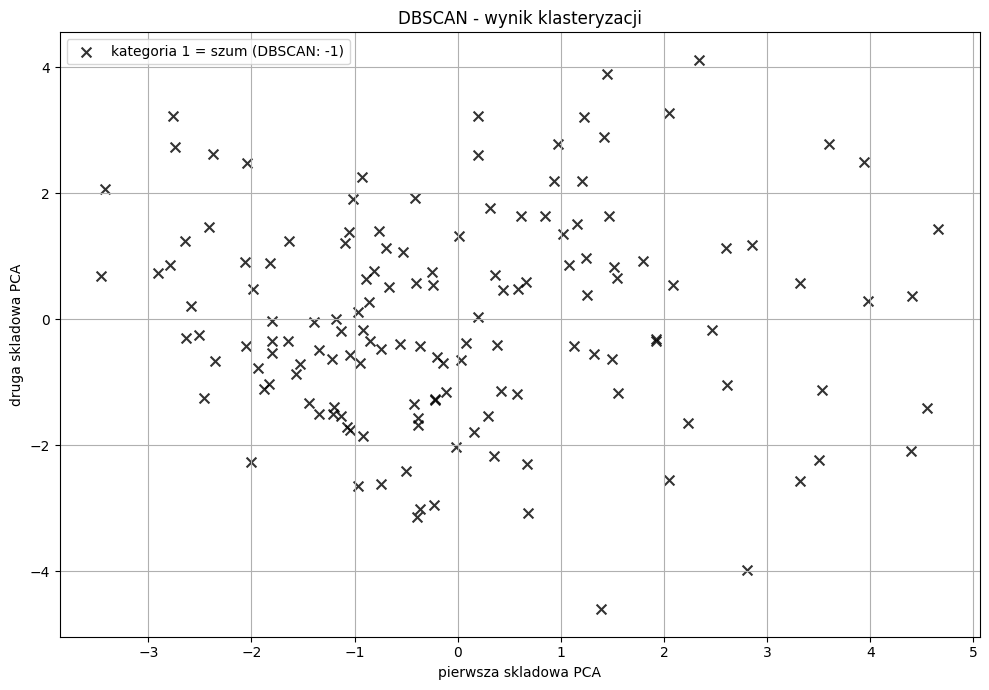

In [29]:
markery = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]
kolory = ["red", "blue", "green", "purple", "orange", "brown", "pink", "gray", "olive", "cyan"]

plt.figure(figsize=(10, 7))

unikalne_raw = sorted(ramka_wykres["raw"].unique())

for i, raw_label in enumerate(unikalne_raw):
    fragment = ramka_wykres[ramka_wykres["raw"] == raw_label]
    kat = fragment["kategoria"].iloc[0]

    if raw_label == -1:
        plt.scatter(
            fragment["x"],
            fragment["y"],
            c="black",
            marker="x",
            s=50,
            label=f"kategoria {kat} = szum (DBSCAN: -1)",
            alpha=0.8
        )
    else:
        plt.scatter(
            fragment["x"],
            fragment["y"],
            c=kolory[i % len(kolory)],
            marker=markery[i % len(markery)],
            s=50,
            label=f"kategoria {kat} = klaster {raw_label}",
            alpha=0.8
        )

plt.title("DBSCAN - wynik klasteryzacji")
plt.xlabel("pierwsza skladowa PCA")
plt.ylabel("druga skladowa PCA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

DBSCAN z domyślnymi parametrami nie wykrył żadnych skupień i przypisał wszystkim obserwacjom etykietę -1 (szum). Taki wynik jest możliwy dla danych o dużej liczbie wymiarów i przy domyślnym eps=0.5, szczególnie gdy cechy mają charakter ankietowy/kategoryczny. Wykres PCA służy jedynie wizualizacji i nie był przestrzenią, w której DBSCAN wyznaczał sąsiedztwa.

Zadanie 4. Korzystając z miary silhouette, a dokładnie średniej miary silhouette dla wszystkich klastrów
oblicz i zaprezentuj graficznie optymalne liczby klastrów dla każdego z analizowanych
algorytmów w zakresie od 2 do 15 klastrów.

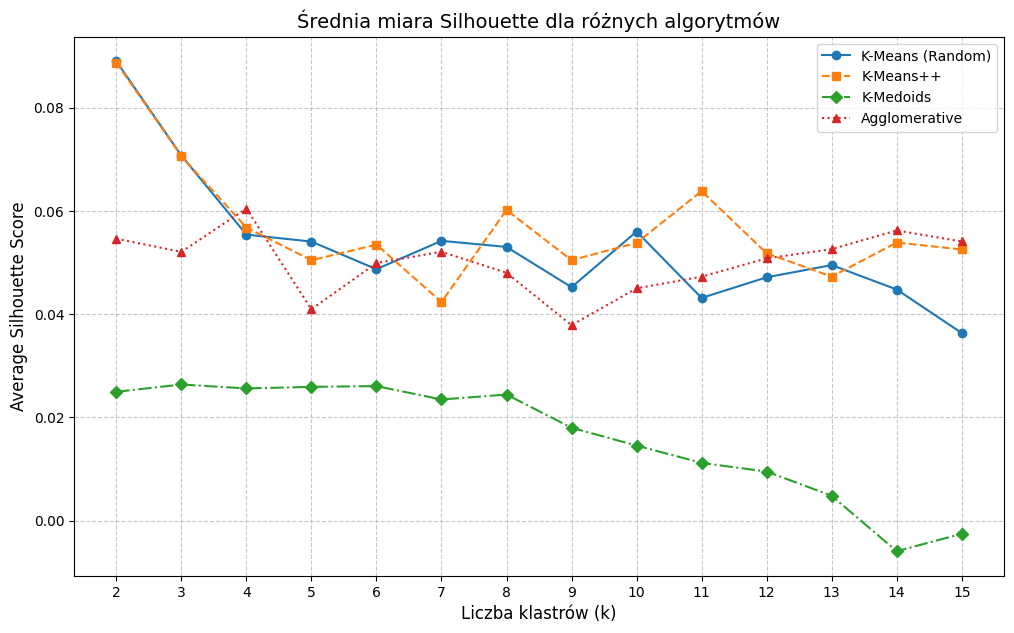

Optymalna liczba klastrów dla K-Means: 2 (Silhouette: 0.0890)
Optymalna liczba klastrów dla K-Means++: 2 (Silhouette: 0.0887)
Optymalna liczba klastrów dla K-Medoids: 3 (Silhouette: 0.0264)
Optymalna liczba klastrów dla Agglomerative: 4 (Silhouette: 0.0605)


In [32]:

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids


X_eval = X_scaled

cluster_range = range(2, 16)

results = {
    'K-Means': [],
    'K-Means++': [],
    'K-Medoids': [],
    'Agglomerative': []
}


for k in cluster_range:
    km = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)
    labels_km = km.fit_predict(X_eval)
    results['K-Means'].append(silhouette_score(X_eval, labels_km))

    km_plus = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_km_plus = km_plus.fit_predict(X_eval)
    results['K-Means++'].append(silhouette_score(X_eval, labels_km_plus))

    try:
        kmed = KMedoids(n_clusters=k, random_state=42)
        labels_kmed = kmed.fit_predict(X_eval)
        results['K-Medoids'].append(silhouette_score(X_eval, labels_kmed))
    except (NameError, Exception):
        pass

    agg = AgglomerativeClustering(n_clusters=k)
    labels_agg = agg.fit_predict(X_eval)
    results['Agglomerative'].append(silhouette_score(X_eval, labels_agg))

plt.figure(figsize=(12, 7))

plt.plot(cluster_range, results['K-Means'], marker='o', linestyle='-', label='K-Means (Random)')
plt.plot(cluster_range, results['K-Means++'], marker='s', linestyle='--', label='K-Means++')
plt.plot(cluster_range, results['K-Medoids'], marker='D', linestyle='-.', label='K-Medoids')
plt.plot(cluster_range, results['Agglomerative'], marker='^', linestyle=':', label='Agglomerative')

plt.title('Średnia miara Silhouette dla różnych algorytmów', fontsize=14)
plt.xlabel('Liczba klastrów (k)', fontsize=12)
plt.ylabel('Average Silhouette Score', fontsize=12)
plt.xticks(cluster_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

for algo, scores in results.items():
    if scores:
        best_k = cluster_range[scores.index(max(scores))]
        print(f"Optymalna liczba klastrów dla {algo}: {best_k} (Silhouette: {max(scores):.4f})")